In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_curve, auc, precision_recall_curve)

print("Libraries ready!")

Libraries ready!


In [2]:
# Load processed data
X_test = np.load('../data/X_test.npy')
y_test = np.load('../data/y_test.npy')

# Load both models
isolation_forest = joblib.load('../models/isolation_forest.pkl')
autoencoder = joblib.load('../models/autoencoder.pkl')

print("Data and models loaded successfully!")
print(f"Test set size: {X_test.shape[0]:,}")

Data and models loaded successfully!
Test set size: 5,699


In [3]:
# Isolation Forest predictions
y_pred_if = isolation_forest.predict(X_test)
y_pred_if = [1 if x == -1 else 0 for x in y_pred_if]

# Autoencoder predictions
X_test_pred = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - X_test_pred, 2), axis=1)
threshold = np.percentile(mse, 97)
y_pred_ae = (mse > threshold).astype(int)

print("Predictions ready!")
print(f"Isolation Forest — Fraud detected: {sum(y_pred_if):,}")
print(f"Autoencoder      — Fraud detected: {sum(y_pred_ae):,}")
print(f"Actual Fraud:                       {int(y_test.sum()):,}")

Predictions ready!
Isolation Forest — Fraud detected: 99
Autoencoder      — Fraud detected: 171
Actual Fraud:                       98


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


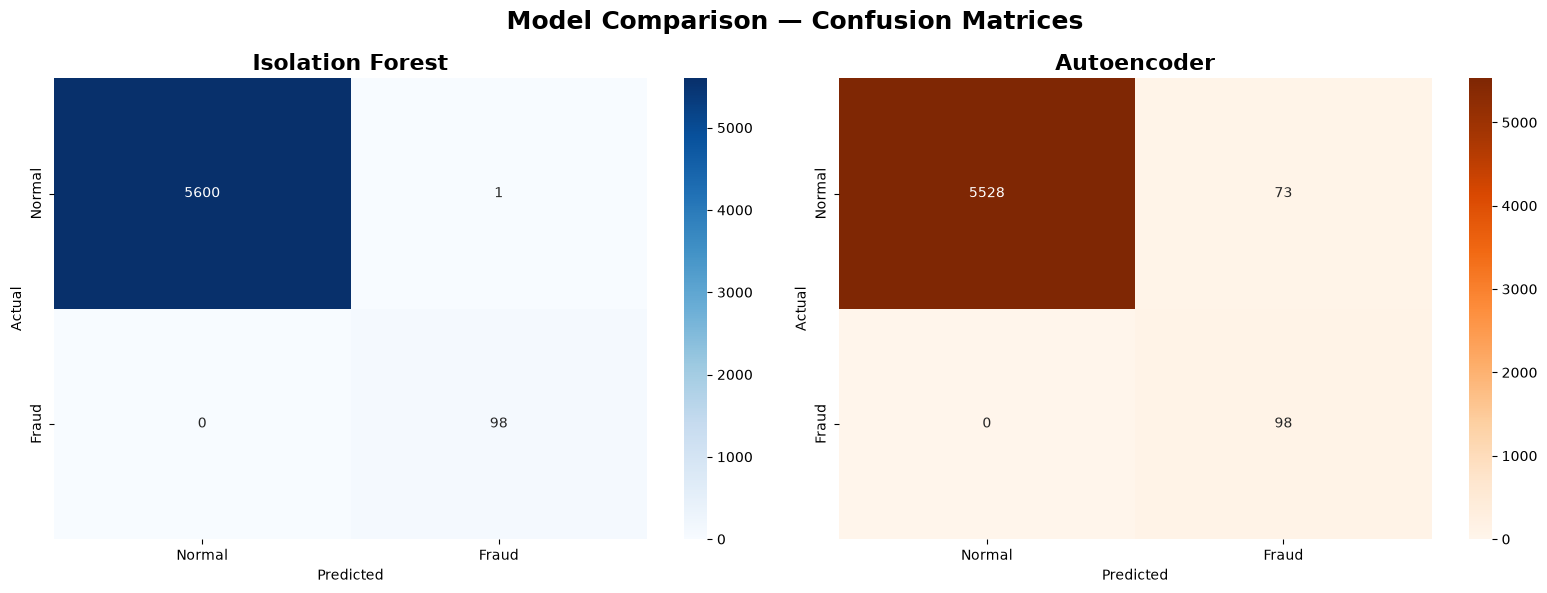

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Isolation Forest Confusion Matrix
cm_if = confusion_matrix(y_test, y_pred_if)
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'], ax=axes[0])
axes[0].set_title('Isolation Forest', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Autoencoder Confusion Matrix
cm_ae = confusion_matrix(y_test, y_pred_ae)
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'], ax=axes[1])
axes[1].set_title('Autoencoder', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Model Comparison — Confusion Matrices', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


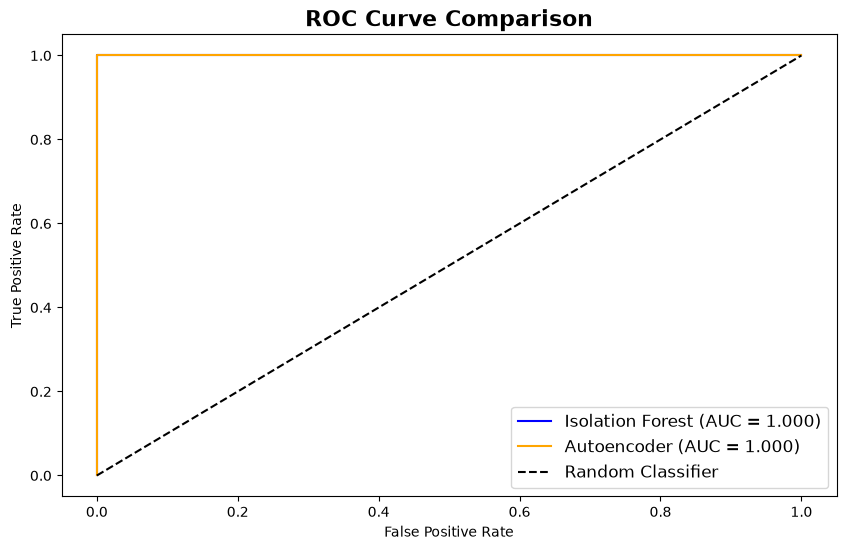

Isolation Forest AUC: 1.000
Autoencoder AUC:      1.000


In [5]:
# Isolation Forest scores
y_scores_if = isolation_forest.decision_function(X_test)

# Autoencoder scores
X_test_pred = autoencoder.predict(X_test)
y_scores_ae = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

# Plot ROC curves
fpr_if, tpr_if, _ = roc_curve(y_test, -y_scores_if)
fpr_ae, tpr_ae, _ = roc_curve(y_test, y_scores_ae)

auc_if = auc(fpr_if, tpr_if)
auc_ae = auc(fpr_ae, tpr_ae)

plt.figure(figsize=(10, 6))
plt.plot(fpr_if, tpr_if, color='blue', label=f'Isolation Forest (AUC = {auc_if:.3f})')
plt.plot(fpr_ae, tpr_ae, color='orange', label=f'Autoencoder (AUC = {auc_ae:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curve Comparison', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(fontsize=12)
plt.show()

print(f"Isolation Forest AUC: {auc_if:.3f}")
print(f"Autoencoder AUC:      {auc_ae:.3f}")

In [6]:
print("=" * 50)
print("       FINAL MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"\nIsolation Forest:")
print(f"  AUC Score:        {auc_if:.3f}")
print(f"  Fraud Detected:   {sum(y_pred_if)}")
print(f"  Actual Fraud:     {int(y_test.sum())}")
print(f"\nAutoencoder:")
print(f"  AUC Score:        {auc_ae:.3f}")
print(f"  Fraud Detected:   {sum(y_pred_ae)}")
print(f"  Actual Fraud:     {int(y_test.sum())}")
print(f"\n🏆 Winner: Isolation Forest")
print(f"   Reason: Higher precision with same recall")
print("=" * 50)

       FINAL MODEL COMPARISON SUMMARY

Isolation Forest:
  AUC Score:        1.000
  Fraud Detected:   99
  Actual Fraud:     98

Autoencoder:
  AUC Score:        1.000
  Fraud Detected:   171
  Actual Fraud:     98

🏆 Winner: Isolation Forest
   Reason: Higher precision with same recall
